In [1]:
import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "max_split_size_mb:128"
os.environ["KERAS_BACKEND"] = "torch"
import keras
import torch

In [2]:
keras.mixed_precision.set_global_policy('mixed_bfloat16')

In [3]:
import pickle
import tarfile
import datetime
import numpy as np
import pandas as pd
import urllib.request
import sklearn.metrics
import matplotlib.pyplot as plt
import zipfile
from joblib import Parallel, delayed
import albumentations as A

from pathlib import Path
import cv2
from typing import Literal

In [4]:
print('CUDA:', torch.version.cuda)
print('GPU:', torch.cuda.is_available())

CUDA: 12.8
GPU: True


In [5]:
BATCH_SIZE = 8
LOGS_DIR = '../logs'
DATA_DIR = '../data'

os.makedirs(LOGS_DIR, exist_ok=True)
os.makedirs(DATA_DIR, exist_ok=True)

In [6]:
class SegmentationDataset(keras.utils.PyDataset):

    def __init__(
        self,
        path: Path,
        *,
        batch_size: int = 32,
        augmentations: A.Compose | None = None,
        seed: int | None = None,
        shuffle: bool = True,
        **kwargs,
    ):
        super().__init__(**kwargs)
        self.path = path
        self.batch_size = batch_size
        self.augmentations = augmentations
        self.data_amount = len(list(path.iterdir())) // 2
        self.rng = np.random.default_rng(seed)
        self.shuffle = shuffle

        self.data_paths = []
        self.masks_paths = []

        for i in range(1, self.data_amount):
            data = path / f"{i}.png"
            mask = path / f"{i}_outline.png"

            self.data_paths.append(data)
            self.masks_paths.append(mask)

        self.indices = np.arange(len(self.data_paths))

        self.data = np.array(
            [
                cv2.cvtColor(self.safe_read(path), cv2.COLOR_BGR2RGB)
                for path in self.data_paths
            ]
        )
        self.masks = (
            np.array(
                [
                    cv2.cvtColor(self.safe_read(path), cv2.COLOR_BGR2GRAY)
                    for path in self.masks_paths
                ]
            )
            > 0
        ).astype(np.uint8)

        self.on_epoch_end()

    def safe_read(self, path) -> np.ndarray:
        img = cv2.imread(str(path))
        if img is None:
            raise ValueError(f"Could not read image at {path}")
        return img

    def __len__(self) -> int:
        return int(np.ceil(len(self.data_paths) / self.batch_size))

    def __getitem__(self, idx) -> tuple[np.ndarray, np.ndarray]:
        start = idx * self.batch_size
        end = min(start + self.batch_size, len(self.data_paths))
        batch_indices = self.indices[start:end]

        data = self.data[batch_indices]
        masks = self.masks[batch_indices]

        if self.augmentations is not None:
            augmented = [
                self.augmentations(image=img, mask=mask)
                for img, mask in zip(data, masks)
            ]

            for i, aug in enumerate(augmented):
                data[i] = aug["image"]
                masks[i] = aug["mask"]

        return data, masks

    def on_epoch_end(self):
        if self.shuffle:
            self.rng.shuffle(self.indices)

In [7]:
segmentation_path = Path("../data/segmentation")

In [8]:
augment = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),

    A.Affine(
        scale=(0.8, 1.2),
        rotate=(-45, 45),
        translate_percent=(0.0, 0.1),
        shear=(-10, 10),
        p=0.7
    ),

    A.ElasticTransform(
        alpha=50,
        sigma=5,
        p=0.3
    ),

    A.GridDistortion(p=0.2),

    A.RandomBrightnessContrast(
        brightness_limit=0.25,
        contrast_limit=0.25,
        p=0.5
    ),

    A.RandomResizedCrop((512, 512), (0.5, 1), (1, 1), p=0.2),

    A.GaussianBlur(
        blur_limit=(3, 5),
        p=0.2
    ),
], p=1.0)

In [9]:
train_ds = SegmentationDataset(segmentation_path / "train", batch_size=BATCH_SIZE, augmentations=augment)

In [10]:
val_ds = SegmentationDataset(segmentation_path / "val", batch_size=BATCH_SIZE, shuffle=False)

In [11]:
def get_name(name: str | None, suffix: str, sep: str = '_') -> str | None:
    return name + sep + suffix if name else None

In [12]:
def conv_block(
    x: keras.KerasTensor,
    features: int,
    kernel_size: int,
    activation: str = 'relu',
    name: str | None = None
) -> keras.KerasTensor:

    x = keras.layers.Conv2D(features, kernel_size, padding='same', name=get_name(name, 'conv'))(x)
    x = keras.layers.LayerNormalization(name=get_name(name, 'norm'))(x)
    x = keras.layers.Activation(activation, name=get_name(name, 'activation'))(x)

    return x

In [13]:
def unet_block(
    x: keras.KerasTensor,
    features: int,
    depth: int,
    block_size: int,
    activation: str = 'relu',
    conv_pool: bool = False,
    conv_upsample: bool = True
) -> keras.KerasTensor:
    block_name = f'unet_block_{depth}'
    y = x
    for i in range(block_size):
        x = y = conv_block(x, features, kernel_size=3, activation=activation, name=get_name(block_name, f'down_block_{i}'))
        
    if depth == 0: 
        return x
        
    if conv_pool:
        x = keras.layers.Conv2D(features, 2, strides=2, name=get_name(block_name, 'pool_conv'))(x)
    else:
        x = keras.layers.MaxPool2D(name=get_name(block_name, 'pool_max'))(x)
    
    x = unet_block(x, features * 2, depth - 1, block_size, activation, conv_pool)
    if conv_upsample:
        x = keras.layers.Conv2DTranspose(features, 2, strides=2, name=get_name(block_name, 'upsample_conv'))(x)
    else:
        x = keras.layers.UpSampling2D(name=get_name(block_name, 'upsample'))(x)
        
    x = keras.layers.Concatenate(name=get_name(block_name, 'concat'))([x, y])

    for i in range(block_size):
        x = conv_block(x, features, kernel_size=3, activation=activation, name=get_name(block_name, f'up_block_{i}'))

    return x

In [14]:
def unet(
    n_classes: int,
    features: int,
    name: str | None = 'unet',
    top_activation: str | None = None,
    conv_pool: bool = False,
    conv_upsample: bool = True
) -> keras.Model:
    
    x = inputs = keras.layers.Input((None, None, 3), name='Input')
    x = keras.layers.Rescaling(1./255)(x)
    x = unet_block(x, features, 4, 2, activation='silu', conv_pool=conv_pool, conv_upsample=conv_upsample)
    x = keras.layers.Conv2D(n_classes, 1, name='last_conv', activation=top_activation)(x)

    return keras.models.Model(inputs=inputs, outputs=x, name=name)

In [15]:
model = unet(1, 16)

In [16]:
model.summary()

Model: "unet"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ Input (InputLayer)  │ (None, None,      │          0 │ -                 │
│                     │ None, 3)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, None,      │          0 │ Input[0][0]       │
│ (Rescaling)         │ None, 3)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ unet_block_4_down_… │ (None, None,      │        448 │ rescaling[0][0]   │
│ (Conv2D)            │ None, 16)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ unet_block_4_down_… │ (None, None,      │         32 │ unet_block_4_dow… │
│ (LayerNormalizatio… │ None, 16)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ unet_block_4_down_… │ (None, None,      │          0 │ unet_block_4_dow… │
│ (Activation)        │ None, 16)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ unet_block_4_down_… │ (None, None,      │      2,320 │ unet_block_4_dow… │
│ (Conv2D)            │ None, 16)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ unet_block_4_down_… │ (None, None,      │         32 │ unet_block_4_dow… │
│ (LayerNormalizatio… │ None, 16)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ unet_block_4_down_… │ (None, None,      │          0 │ unet_block_4_dow… │
│ (Activation)        │ None, 16)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ unet_block_4_pool_… │ (None, None,      │          0 │ unet_block_4_dow… │
│ (MaxPooling2D)      │ None, 16)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ unet_block_3_down_… │ (None, None,      │      4,640 │ unet_block_4_poo… │
│ (Conv2D)            │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ unet_block_3_down_… │ (None, None,      │         64 │ unet_block_3_dow… │
│ (LayerNormalizatio… │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ unet_block_3_down_… │ (None, None,      │          0 │ unet_block_3_dow… │
│ (Activation)        │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ unet_block_3_down_… │ (None, None,      │      9,248 │ unet_block_3_dow… │
│ (Conv2D)            │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ unet_block_3_down_… │ (None, None,      │         64 │ unet_block_3_dow… │
│ (LayerNormalizatio… │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ unet_block_3_down_… │ (None, None,      │          0 │ unet_block_3_dow… │
│ (Activation)        │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ unet_block_3_pool_… │ (None, None,      │          0 │ unet_block_3_dow… │
│ (MaxPooling2D)      │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ unet_block_2_down_… │ (None, None,      │     18,496 │ unet_block_3_poo

 Total params: 1,944,049 (7.42 MB)

 Trainable params: 1,944,049 (7.42 MB)

 Non-trainable params: 0 (0.00 B)

In [17]:
class BCEPlusDice(keras.losses.Loss):
    def __init__(self, bce_weight=0.5, dice_weight=0.5, from_logits=False, **kwargs):
        super().__init__(**kwargs)
        self.bce_weight = bce_weight
        self.dice_weight = dice_weight
        self.from_logits = from_logits
        self.bce = keras.losses.BinaryCrossentropy(from_logits=from_logits)
        self.dice = keras.losses.Dice()

    def call(self, y_true, y_pred):
        if self.from_logits:
            y_pred_probs = keras.ops.sigmoid(y_pred)
        else:
            y_pred_probs = y_pred

        bce_loss = self.bce(y_true, y_pred)
        dice_loss = self.dice(y_true, y_pred_probs)
        return self.bce_weight * bce_loss + self.dice_weight * dice_loss

    def get_config(self):
        return {
            "bce_weight": self.bce_weight,
            "dice_weight": self.dice_weight,
            "from_logits": self.from_logits,
            **super().get_config()
        }

In [18]:
class TverskyLoss(keras.losses.Loss):
    def __init__(self, alpha=0.3, beta=0.7, smooth=1e-7, from_logits=False, **kwargs):
        super().__init__(**kwargs)
        self.alpha = alpha
        self.beta = beta
        self.smooth = smooth
        self.from_logits = from_logits

    def call(self, y_true, y_pred):
        if self.from_logits:
            y_pred = keras.ops.sigmoid(y_pred)

        y_true = keras.ops.cast(y_true, "float32")
        y_pred = keras.ops.cast(y_pred, "float32")

        y_true_flat = keras.ops.reshape(y_true, (keras.ops.shape(y_true)[0], -1))
        y_pred_flat = keras.ops.reshape(y_pred, (keras.ops.shape(y_pred)[0], -1))

        tp = keras.ops.sum(y_true_flat * y_pred_flat, axis=-1)
        fp = keras.ops.sum((1 - y_true_flat) * y_pred_flat, axis=-1)
        fn = keras.ops.sum(y_true_flat * (1 - y_pred_flat), axis=-1)

        tversky = (tp + self.smooth) / (
            tp + self.alpha * fp + self.beta * fn + self.smooth
        )

        return 1 - tversky

    def get_config(self):
        return {
            "alpha": self.alpha,
            "beta": self.beta,
            "smooth": self.smooth,
            "from_logits": self.from_logits,
            **super().get_config(),
        }

In [19]:
class BinaryIoU(keras.metrics.Metric):
    def __init__(self, threshold=0.5, name="binary_iou", dtype=None, **kwargs):
        super().__init__(name=name, dtype=dtype, **kwargs)
        self.threshold = threshold

        self.intersection = self.add_weight(
            name="intersection", initializer="zeros", shape=()
        )
        self.union = self.add_weight(name="union", initializer="zeros", shape=())

    def update_state(self, y_true, y_pred, sample_weight=None):
        y_pred_bin = keras.ops.cast(y_pred > self.threshold, "float32")
        y_true_bin = keras.ops.cast(y_true > 0.5, "float32")

        y_pred_flat = keras.ops.reshape(y_pred_bin, (-1,))
        y_true_flat = keras.ops.reshape(y_true_bin, (-1,))

        batch_intersection = keras.ops.sum(y_true_flat * y_pred_flat)
        batch_union = keras.ops.sum(y_true_flat) + keras.ops.sum(y_pred_flat) - batch_intersection

        self.intersection.assign_add(batch_intersection)
        self.union.assign_add(batch_union)

    def result(self):
        return self.intersection / (self.union + 1e-7)

    def reset_state(self):
        self.intersection.assign(0.0)
        self.union.assign(0.0)

    def get_config(self):
        config = super().get_config()
        config.update({"threshold": self.threshold})
        return config

    @classmethod
    def from_config(cls, config):
        return cls(**config)

In [20]:
model.compile(
    # loss=BCEPlusDice(bce_weight=0.5, dice_weight=0.5, from_logits=True),
    loss=TverskyLoss(from_logits=True),
    optimizer=keras.optimizers.AdamW(),
    metrics=[BinaryIoU(threshold=0.4)],
)

In [21]:
logdir = os.path.join(LOGS_DIR, "segmentation", datetime.datetime.now().strftime("%Y%m%d-%H%M%S"))

In [22]:
from torch.utils.tensorboard import SummaryWriter

class PyTorchTensorBoard(keras.callbacks.Callback):
    def __init__(self, log_dir):
        super().__init__()
        self.writer = SummaryWriter(log_dir)

    def on_epoch_end(self, epoch, logs=None):
        if logs:
            for key, value in logs.items():
                self.writer.add_scalar(key, value, epoch)

In [23]:
import gc

class Stabilizer(keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

In [24]:
callbacks = [
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss", factor=0.5, patience=6, min_lr=1e-8, verbose=1
    ),
    PyTorchTensorBoard(logdir),
    Stabilizer()
]

In [25]:
model.fit(train_ds, validation_data=val_ds, epochs=200, callbacks=callbacks)

Epoch 1/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 5s 497ms/step - binary_iou: 0.0375 - loss: 0.8889 - val_binary_iou: 0.0566 - val_loss: 0.8407 - learning_rate: 0.0010
Epoch 2/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 402ms/step - binary_iou: 0.0419 - loss: 0.8778 - val_binary_iou: 0.0566 - val_loss: 0.8390 - learning_rate: 0.0010
Epoch 3/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 390ms/step - binary_iou: 0.0400 - loss: 0.8825 - val_binary_iou: 0.0566 - val_loss: 0.8381 - learning_rate: 0.0010
Epoch 4/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 379ms/step - binary_iou: 0.0417 - loss: 0.8759 - val_binary_iou: 0.0566 - val_loss: 0.8292 - learning_rate: 0.0010
Epoch 5/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 368ms/step - binary_iou: 0.0638 - loss: 0.8563 - val_binary_iou: 0.1230 - val_loss: 0.7881 - learning_rate: 0.0010
Epoch 6/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 372ms/step - binary_iou: 0.1171 - loss: 0.8057 - val_binary_iou: 0.1263 - val_loss: 0.7396 - learning_rate: 0.0010
Epoch 7/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 340ms/step - binary_iou: 0.104

KeyboardInterrupt: 

In [26]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.gridspec as gridspec

plt.rcParams.update({'font.size': 10})

reds = mcolors.ListedColormap([(1, 1, 1, 0), 'red'])
greens = mcolors.ListedColormap([(1, 1, 1, 0), 'green'])
blacks = mcolors.ListedColormap(['black', 'white'])

In [27]:
def confusion_image(image: np.ndarray, y_true: np.ndarray, y_pred: np.ndarray):
    """Выводит изображение:
        - белое - совпадения
        - красное - ошибочные предсказания
        - зеленое - не предсказанные реальные
        - черное - фон
    """
    fig = plt.figure(figsize=(15, 6), dpi=300)
    gs = gridspec.GridSpec(2, 5, figure=fig)

    ax_image = fig.add_subplot(gs[:, :2])
    ax_image.imshow(image, interpolation=None)
    ax_image.set_title("Image")
    ax_image.axis(False)

    ax_true = fig.add_subplot(gs[0, 2])
    ax_true.imshow(y_true, interpolation=None, cmap="gray")
    ax_true.set_title("True")
    ax_true.axis(False)

    ax_pred = fig.add_subplot(gs[1, 2])
    ax_pred.imshow(y_pred, interpolation=None, cmap="gray")
    ax_pred.set_title("Predicted")
    ax_pred.axis(False)

    ax_overlay = fig.add_subplot(gs[:, 3:])
    ax_overlay.set_title("Difference")
    ax_overlay.axis(False)
    
    ax_overlay.imshow((y_true > 0) & (y_pred > 0), cmap=blacks, interpolation=None)
    ax_overlay.imshow((y_true == 0) & (y_pred > 0), cmap=reds, interpolation=None)
    ax_overlay.imshow((y_true > 0) & (y_pred == 0), cmap=greens, interpolation=None)

    plt.tight_layout()

In [28]:
y_pred = np.squeeze(model.predict(val_ds))

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step


In [29]:
example_idx = 1

In [30]:
binary_mask = (y_pred[example_idx] > 0.4).astype(np.uint8)

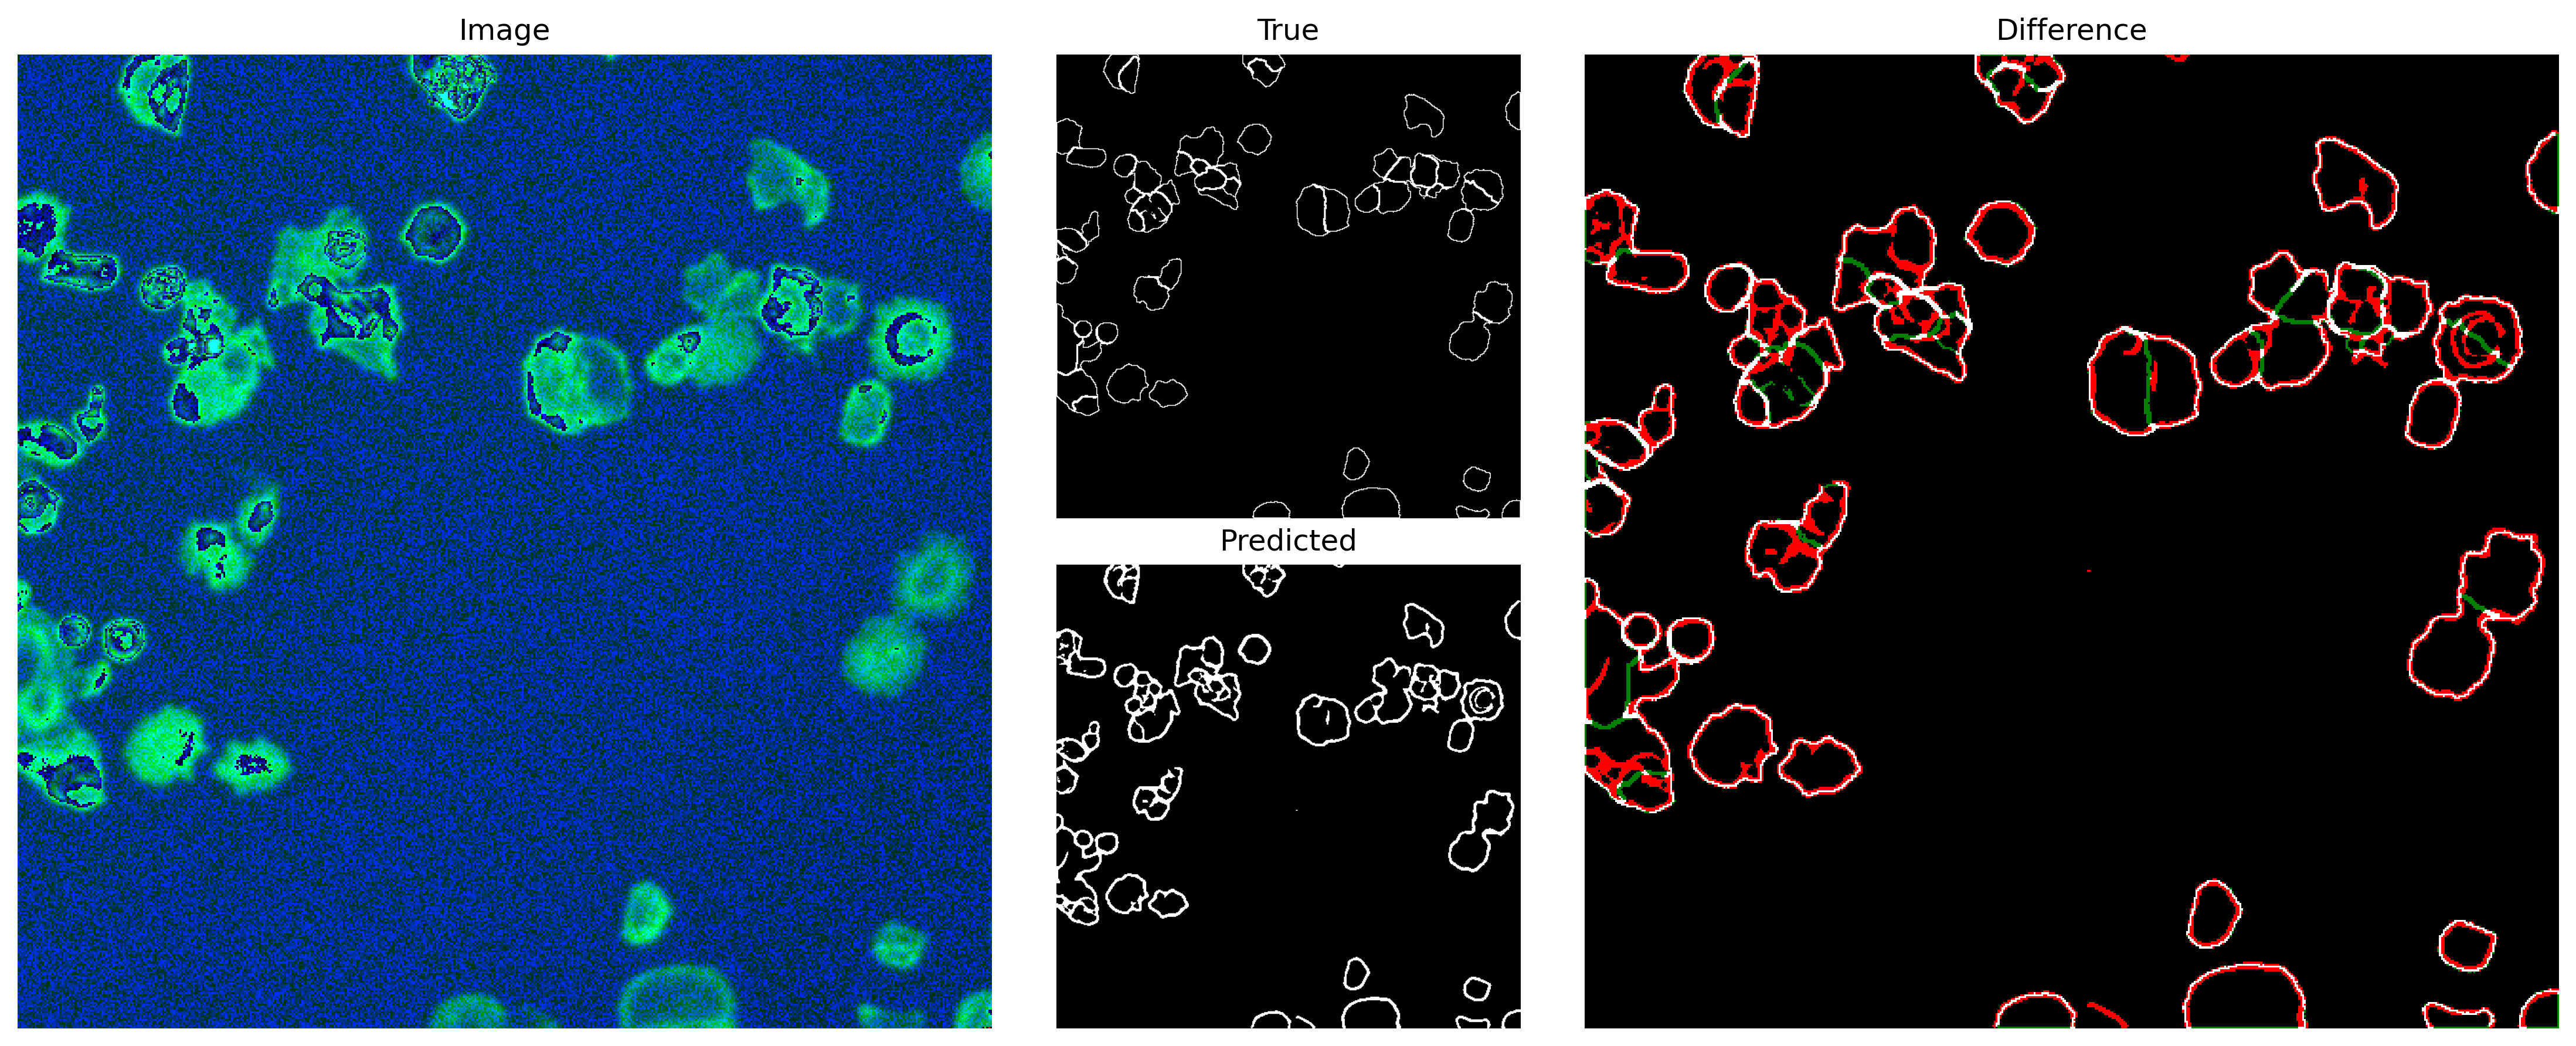

In [31]:
confusion_image(val_ds[0][0][example_idx], val_ds[0][1][example_idx], binary_mask)